🚀 Starting Random Forest Classification Analysis...
🔄 Loading and preparing data...
✅ Data loaded successfully! Total Shape: (6312, 2782)
📊 Labeled samples: 454
🔍 Unlabeled samples: 5858
🎯 Target classes in labeled data: ['Alfalfa-polygon', 'Bare-polygon', 'Clover-polygon', 'Corn-polygon', 'Degreed_Wetland_Poly-polygon', 'Mixed_TP-polygon', 'Phragmites-polygon', 'Plowed-polygon', 'Rice-polygon', 'Sugar_Beet-polygon', 'Tamarix-polygon', 'Urban-polygon', 'Wheat-polygon']
🔧 Found 2780 feature columns
✅ Data preparation completed!
   Classes: ['Alfalfa-polygon', 'Bare-polygon', 'Clover-polygon', 'Corn-polygon', 'Degreed_Wetland_Poly-polygon', 'Mixed_TP-polygon', 'Phragmites-polygon', 'Plowed-polygon', 'Rice-polygon', 'Sugar_Beet-polygon', 'Tamarix-polygon', 'Urban-polygon', 'Wheat-polygon']
🔄 Splitting labeled data (70% train, 30% test)...
✅ Labeled data split completed!
   Training set: 317 samples
   Testing set: 137 samples
🌲 Training Random Forest model on labeled data...
🔮 Predicting 

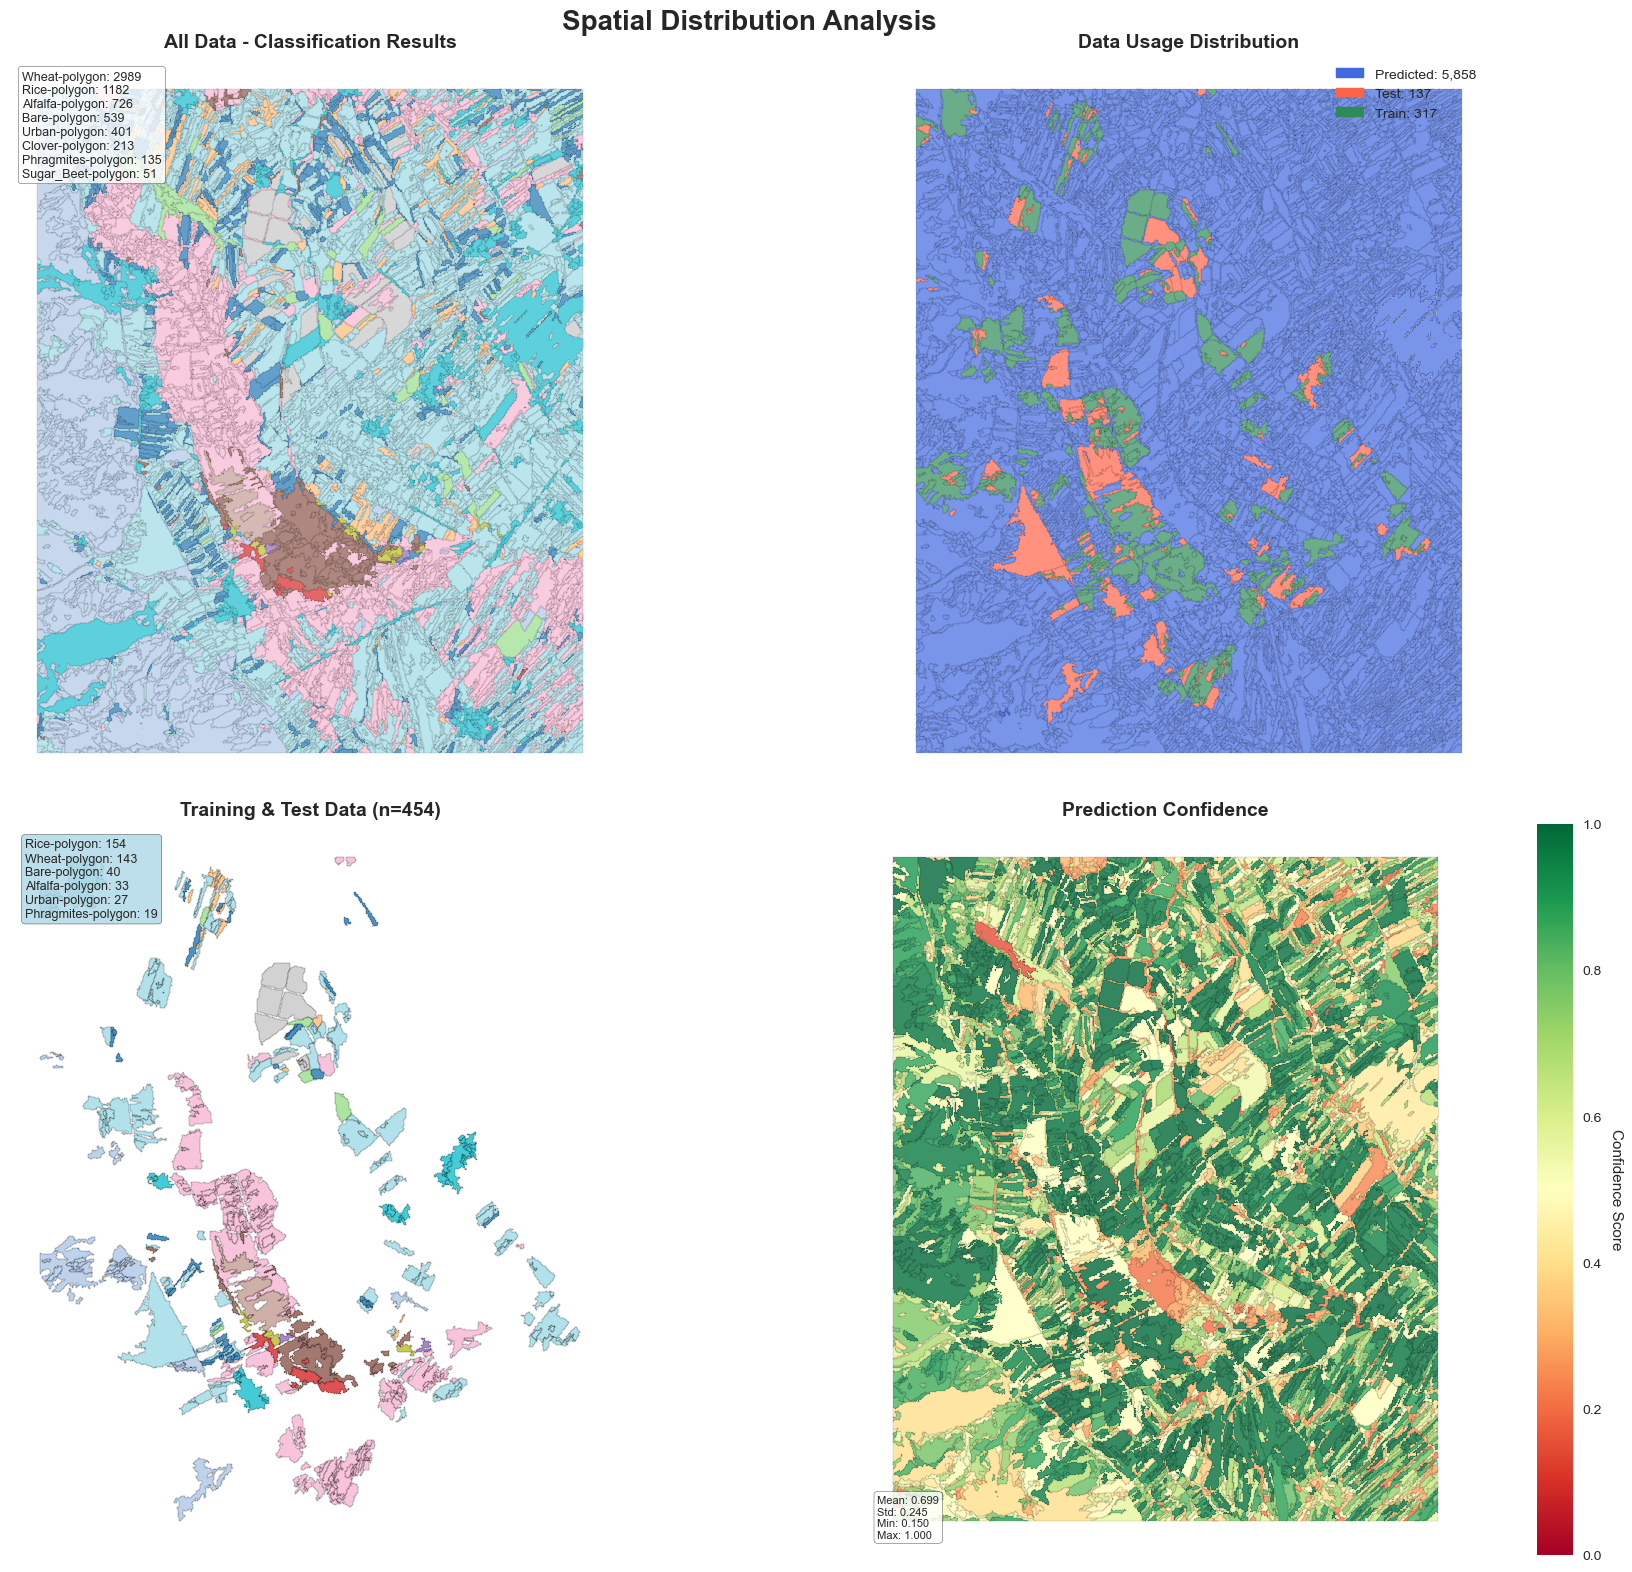

✅ Saved as GeoJSON: RF_Merged_Classification_Results_Raw_Data/predictions.geojson
⚠️  Could not save Shapefile: GeoDataFrame cannot contain duplicated column names.

🗺️  SPATIAL ANALYSIS SUMMARY:
   📊 Total geometries plotted: 6,312
   🎯 Coordinate system: EPSG:4326
   📐 Bounds: 48.761003, 33.835674 to 48.792803, 33.757610
   🏷️  Spatial class distribution:
      Wheat-polygon: 2,989 geometries
      Rice-polygon: 1,182 geometries
      Alfalfa-polygon: 726 geometries
      Bare-polygon: 539 geometries
      Urban-polygon: 401 geometries
      Clover-polygon: 213 geometries
      Phragmites-polygon: 135 geometries
      Sugar_Beet-polygon: 51 geometries
      Corn-polygon: 48 geometries
      Tamarix-polygon: 14 geometries
      ... and 3 more classes
   📈 Confidence statistics:
      Mean: 0.699
      Std:  0.245
      Min:  0.150
      Max:  1.000
✅ Enhanced prediction maps created successfully!
📈 Creating visualizations...


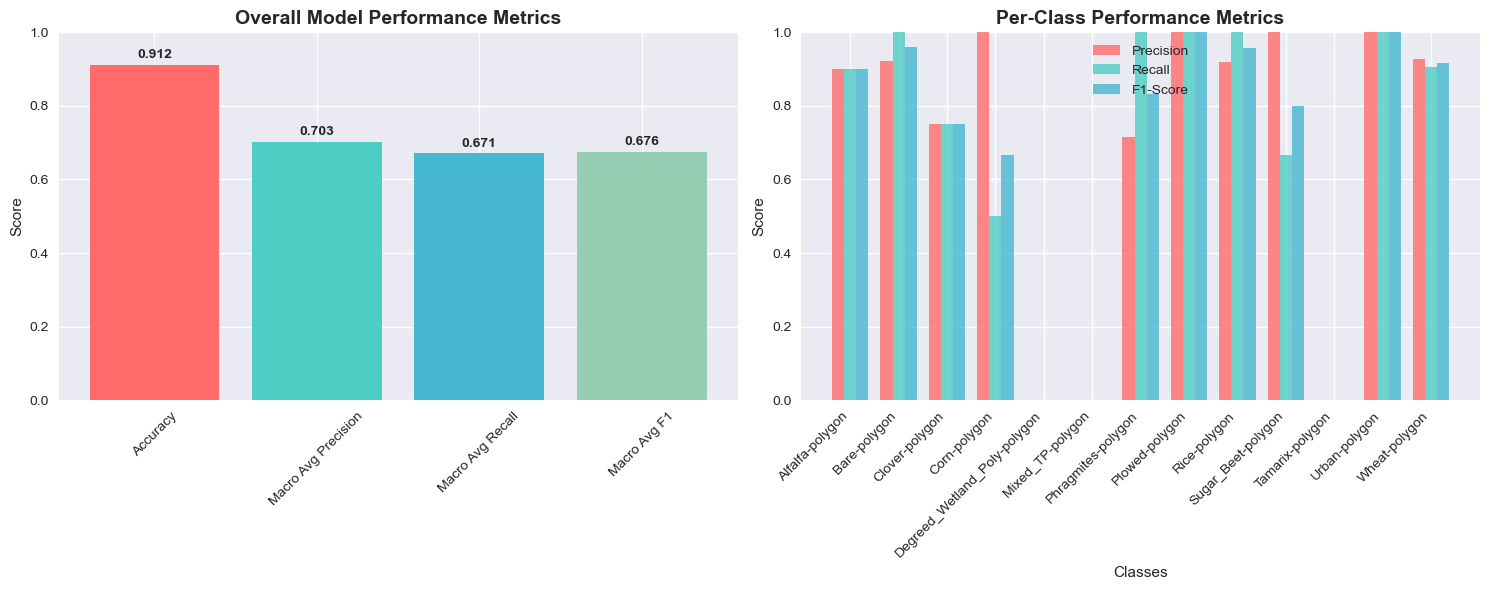

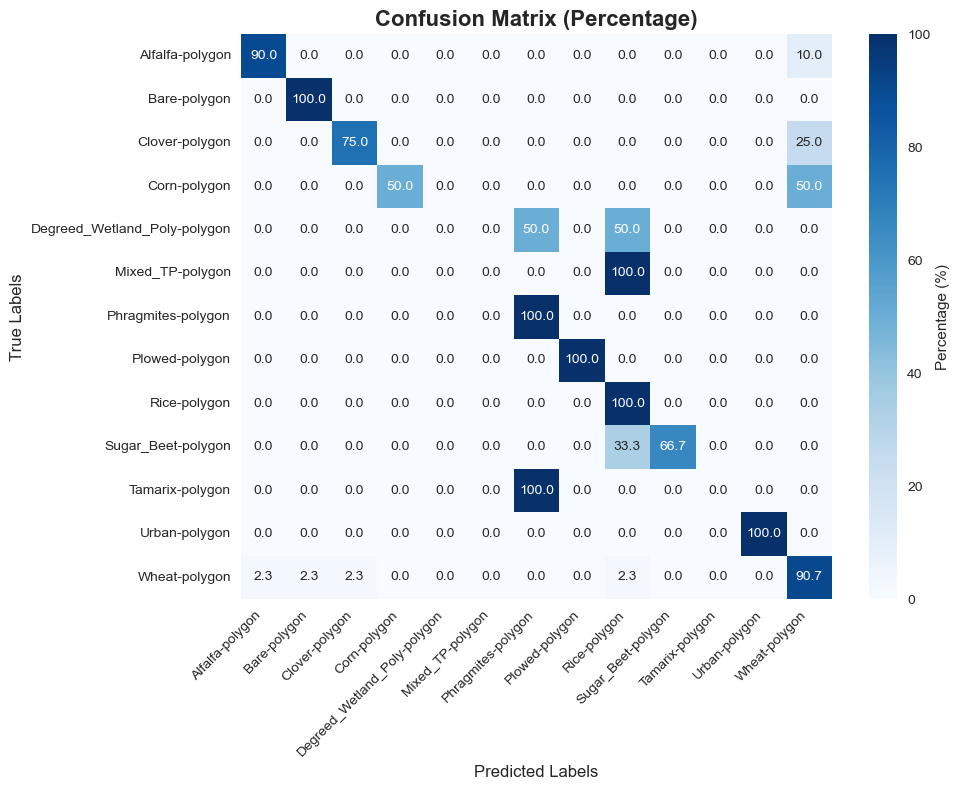

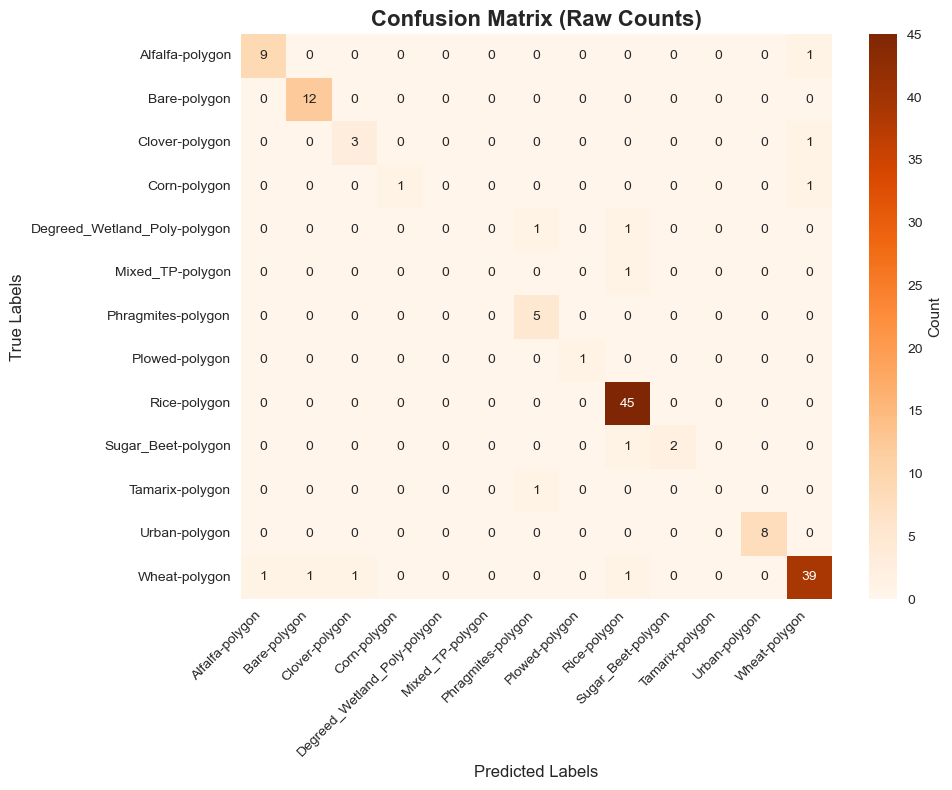

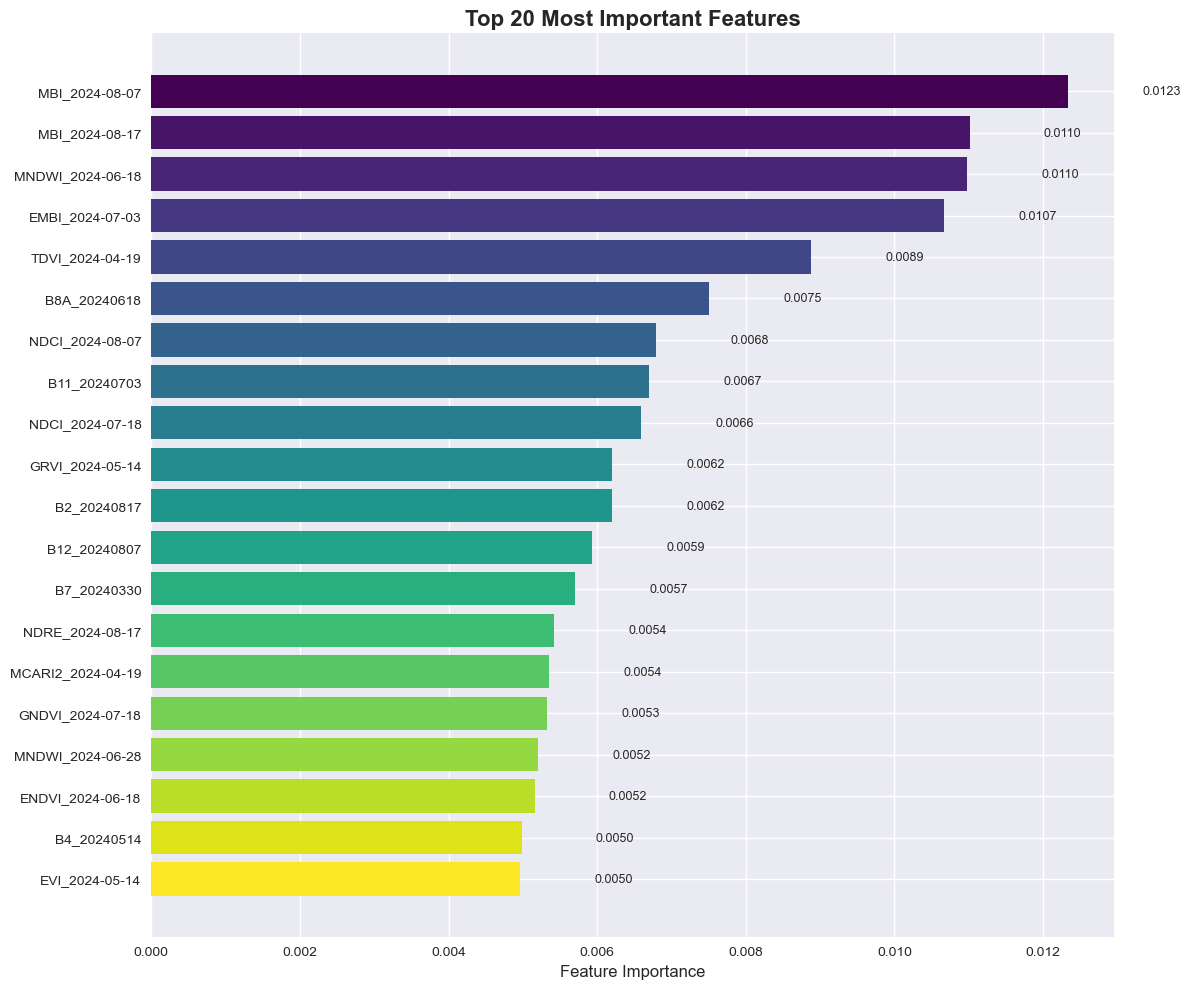

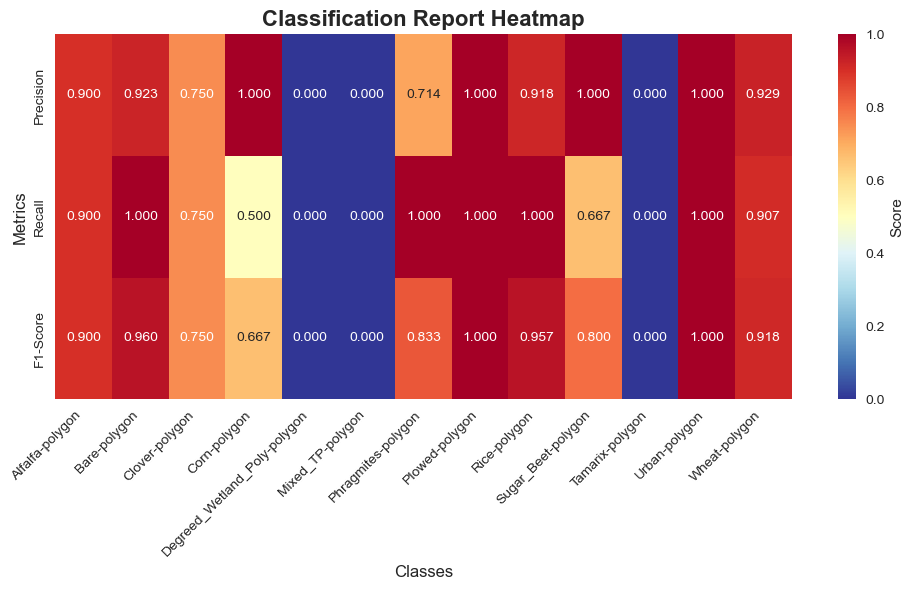

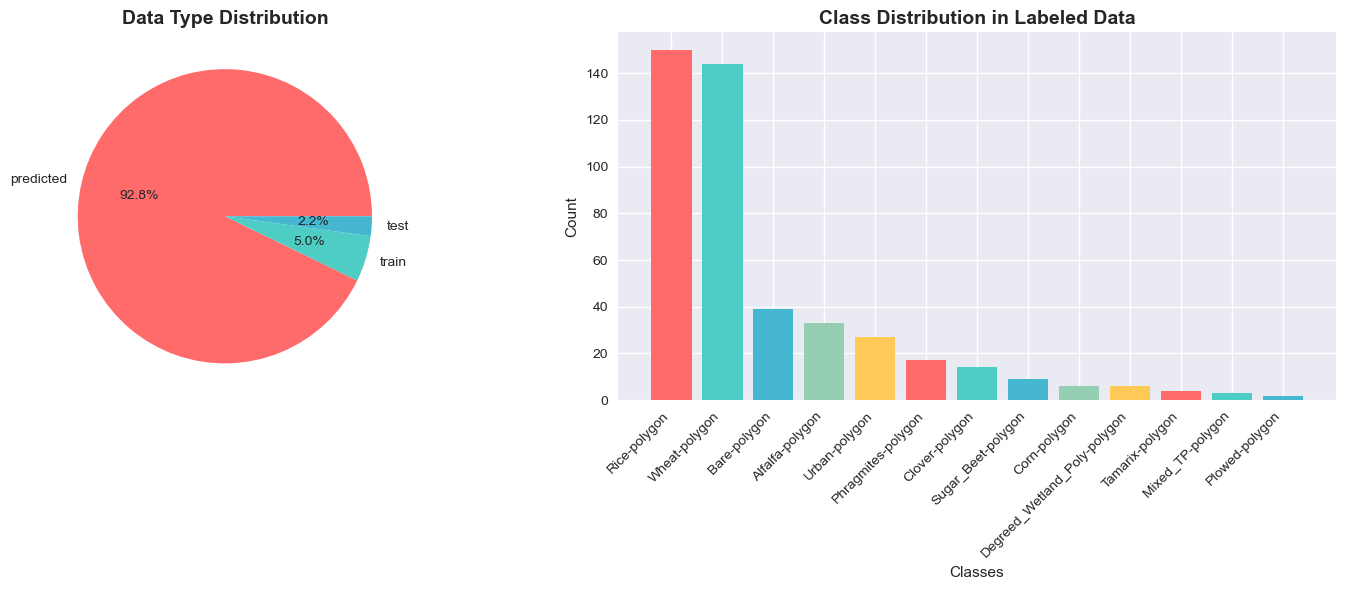

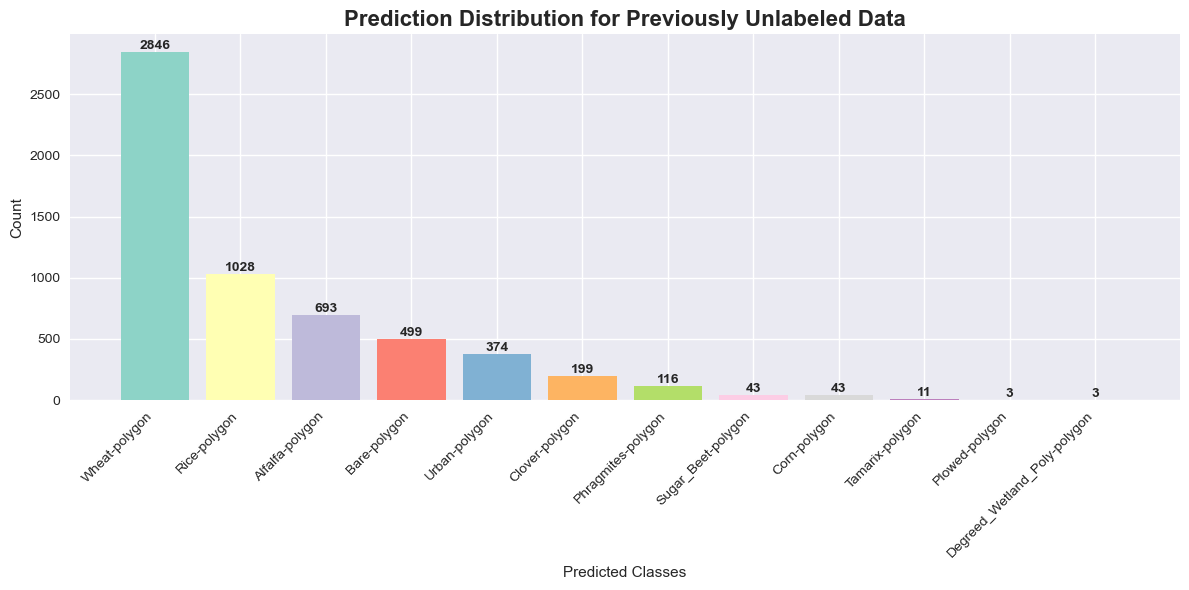

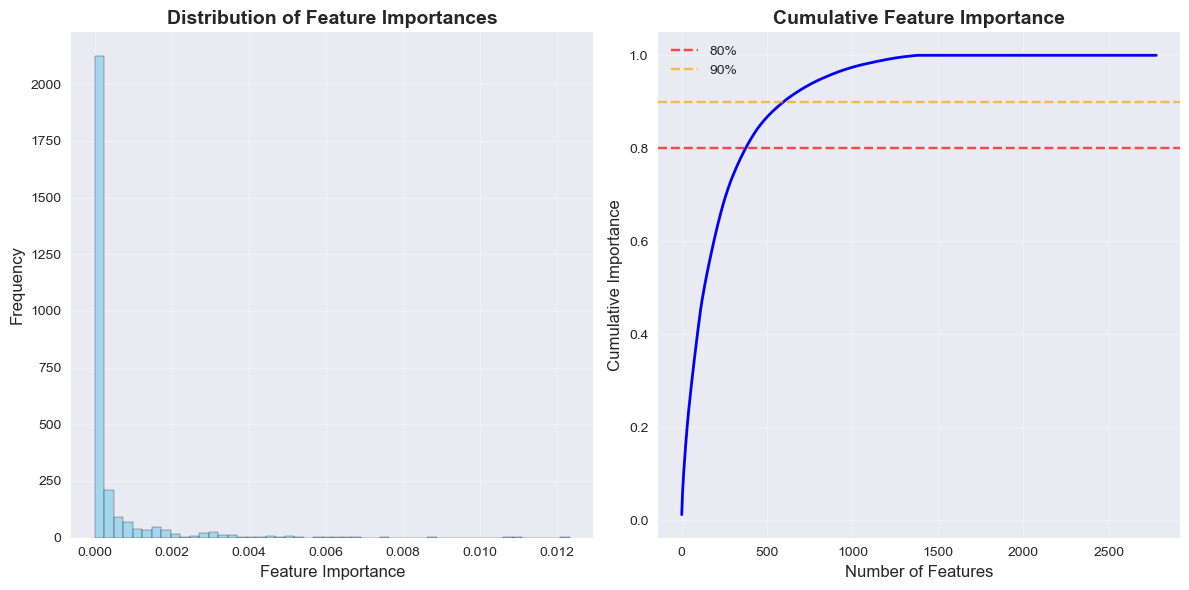

✅ All visualizations created and saved!
💾 Saving results...
✅ All results saved in 'RF_Merged_Classification_Results_Raw_Data' directory!
   📊 Model: RF_Merged_Classification_Results_Raw_Data/random_forest_model.joblib
   🔧 Label Encoder: RF_Merged_Classification_Results_Raw_Data/label_encoder.joblib
   📈 Feature Importance: RF_Merged_Classification_Results_Raw_Data/feature_importance.csv
   📋 Classification Report: RF_Merged_Classification_Results_Raw_Data/classification_report.csv
   🎯 Confusion Matrix: RF_Merged_Classification_Results_Raw_Data/confusion_matrix.csv
   📄 Complete Results: RF_Merged_Classification_Results_Raw_Data/complete_results.json
   📝 Summary Report: RF_Merged_Classification_Results_Raw_Data/summary_report.txt
   🗃️ Final Dataset: RF_Merged_Classification_Results_Raw_Data/final_dataset_with_predictions.csv
🎉 Analysis completed successfully!
📁 Check 'RF_Merged_Classification_Results_Raw_Data' folder for all results and visualizations

📊 ANALYSIS SUMMARY
🎯 Test Acc

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                           precision_recall_fscore_support, roc_curve, auc)
from sklearn.preprocessing import LabelEncoder
import joblib
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class RFClassificationAnalysis:
    def __init__(self, csv_path):
        """
        Initialize the Random Forest Classification Analysis
        
        Args:
            csv_path (str): Path to the CSV file
        """
        self.csv_path = csv_path
        self.df = None
        self.labeled_data = None
        self.unlabeled_data = None
        self.X_labeled = None
        self.y_labeled = None
        self.X_unlabeled = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.model = None
        self.y_pred_test = None
        self.y_pred_unlabeled = None
        self.feature_names = None
        self.class_names = None
        self.label_encoder = None
        self.results = {}
        
        # Create results directory
        self.results_dir = "RF_Merged_Classification_Results_Raw_Data"
        os.makedirs(self.results_dir, exist_ok=True)
        
    def load_and_prepare_data(self):
        """Load CSV and separate labeled from unlabeled data"""
        print("🔄 Loading and preparing data...")
        
        # Load CSV
        self.df = pd.read_csv(self.csv_path)
        print(f"✅ Data loaded successfully! Total Shape: {self.df.shape}")
        
        # Check for layer column
        if 'layer' not in self.df.columns:
            raise ValueError("❌ 'layer' column not found in the dataset!")
        
        # Separate labeled and unlabeled data
        # Labeled data: has non-null values in layer column (excluding 'Unknown')
        labeled_mask = (self.df['layer'].notna()) & (self.df['layer'] != '') & (self.df['layer'] != 'Unknown')
        
        self.labeled_data = self.df[labeled_mask].copy()
        self.unlabeled_data = self.df[~labeled_mask].copy()
        
        print(f"📊 Labeled samples: {len(self.labeled_data)}")
        print(f"🔍 Unlabeled samples: {len(self.unlabeled_data)}")
        print(f"🎯 Target classes in labeled data: {sorted(self.labeled_data['layer'].unique())}")
        
        if len(self.labeled_data) == 0:
            raise ValueError("❌ No labeled data found for training!")
        
        # Identify feature columns (exclude geometry, label, layer)
        exclude_cols = ['geometry', 'label', 'layer']
        feature_cols = [col for col in self.df.columns if col not in exclude_cols]
        
        if len(feature_cols) == 0:
            raise ValueError("❌ No feature columns found after excluding geometry, label, and layer!")
        
        print(f"🔧 Found {len(feature_cols)} feature columns")
        
        # Prepare features and target for labeled data
        self.X_labeled = self.labeled_data[feature_cols].fillna(0)  # Fill NaN with 0
        self.y_labeled = self.labeled_data['layer']
        
        # Prepare features for unlabeled data
        if len(self.unlabeled_data) > 0:
            self.X_unlabeled = self.unlabeled_data[feature_cols].fillna(0)
        
        self.feature_names = feature_cols
        
        # Encode labels if they are strings
        if self.y_labeled.dtype == 'object':
            self.label_encoder = LabelEncoder()
            self.y_labeled_encoded = self.label_encoder.fit_transform(self.y_labeled)
            self.class_names = list(self.label_encoder.classes_)
        else:
            self.y_labeled_encoded = self.y_labeled
            self.class_names = sorted(self.y_labeled.unique())
        
        print(f"✅ Data preparation completed!")
        print(f"   Classes: {self.class_names}")
        return self
    
    def split_labeled_data(self, test_size=0.3, random_state=42):
        """Split labeled data into training and testing sets (70-30)"""
        print("🔄 Splitting labeled data (70% train, 30% test)...")
        
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X_labeled, self.y_labeled_encoded, test_size=test_size, 
            random_state=random_state, stratify=self.y_labeled_encoded
        )
        
        print(f"✅ Labeled data split completed!")
        print(f"   Training set: {len(self.X_train)} samples")
        print(f"   Testing set: {len(self.X_test)} samples")
        return self
    
    def train_random_forest(self, n_estimators=100, max_depth=None, random_state=42):
        """Train Random Forest model on labeled data"""
        print("🌲 Training Random Forest model on labeled data...")
        
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_state,
            n_jobs=-1
        )
        
        self.model.fit(self.X_train, self.y_train)
        
        # Make predictions on test set
        self.y_pred_test = self.model.predict(self.X_test)
        
        # Make predictions on unlabeled data
        if len(self.unlabeled_data) > 0:
            print("🔮 Predicting unlabeled data...")
            self.y_pred_unlabeled_encoded = self.model.predict(self.X_unlabeled)
            # Convert back to original labels
            self.y_pred_unlabeled = self.label_encoder.inverse_transform(self.y_pred_unlabeled_encoded)
            print(f"✅ Predicted {len(self.y_pred_unlabeled)} unlabeled samples")
        
        print(f"✅ Model training and prediction completed!")
        return self
    
    def calculate_metrics(self):
        """Calculate all performance metrics"""
        print("📊 Calculating performance metrics...")
        
        # Basic metrics
        accuracy = accuracy_score(self.y_test, self.y_pred_test)
        
        # Classification report
        class_report = classification_report(
            self.y_test, self.y_pred_test, 
            target_names=self.class_names, 
            output_dict=True,
            zero_division=0
        )
        
        # Confusion matrix
        conf_matrix = confusion_matrix(self.y_test, self.y_pred_test)
        
        # Feature importance
        feature_importance = pd.DataFrame({
            'feature': self.feature_names,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        # Prediction distribution for unlabeled data
        unlabeled_predictions_dist = None
        if hasattr(self, 'y_pred_unlabeled'):
            unlabeled_predictions_dist = pd.Series(self.y_pred_unlabeled).value_counts().to_dict()
        
        # Store results
        self.results = {
            'accuracy': accuracy,
            'classification_report': class_report,
            'confusion_matrix': conf_matrix,
            'feature_importance': feature_importance,
            'unlabeled_predictions_distribution': unlabeled_predictions_dist,
            'model_params': self.model.get_params(),
            'data_info': {
                'total_samples': len(self.df),
                'labeled_samples': len(self.labeled_data),
                'unlabeled_samples': len(self.unlabeled_data),
                'train_samples': len(self.X_train),
                'test_samples': len(self.X_test),
                'n_features': len(self.feature_names),
                'n_classes': len(self.class_names),
                'class_names': self.class_names
            }
        }
        
        print(f"✅ Metrics calculated!")
        print(f"🎯 Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
        if unlabeled_predictions_dist:
            print(f"🔮 Unlabeled predictions distribution:")
            for class_name, count in unlabeled_predictions_dist.items():
                print(f"   {class_name}: {count} samples")
        return self
    
    def create_final_dataset_with_predictions(self):
        """Create final dataset with all predictions"""
        print("📋 Creating final dataset with predictions...")
        
        # Create a copy of the original dataframe
        final_df = self.df.copy()
        
        # Add prediction columns
        final_df['prediction'] = None
        final_df['prediction_confidence'] = None
        final_df['data_type'] = 'unlabeled'  # Default
        
        # Mark labeled data
        labeled_mask = (final_df['layer'].notna()) & (final_df['layer'] != '') & (final_df['layer'] != 'Unknown')
        final_df.loc[labeled_mask, 'data_type'] = 'labeled'
        final_df.loc[labeled_mask, 'prediction'] = final_df.loc[labeled_mask, 'layer']
        
        # Add test predictions (for evaluation)
        test_indices = self.X_test.index
        test_predictions = self.label_encoder.inverse_transform(self.y_pred_test)
        final_df.loc[test_indices, 'prediction'] = test_predictions
        final_df.loc[test_indices, 'data_type'] = 'test'
        
        # Add training data predictions (should be perfect)
        train_indices = self.X_train.index
        train_predictions = self.label_encoder.inverse_transform(self.y_train)
        final_df.loc[train_indices, 'prediction'] = train_predictions
        final_df.loc[train_indices, 'data_type'] = 'train'
        
        # Add unlabeled predictions
        if hasattr(self, 'y_pred_unlabeled'):
            unlabeled_indices = self.unlabeled_data.index
            final_df.loc[unlabeled_indices, 'prediction'] = self.y_pred_unlabeled
            final_df.loc[unlabeled_indices, 'data_type'] = 'predicted'
            
            # Add prediction probabilities as confidence
            pred_proba = self.model.predict_proba(self.X_unlabeled)
            confidence = np.max(pred_proba, axis=1)
            final_df.loc[unlabeled_indices, 'prediction_confidence'] = confidence
        
        # Save final dataset
        final_csv_path = f'{self.results_dir}/final_dataset_with_predictions.csv'
        final_df.to_csv(final_csv_path, index=False)
        
        self.final_df = final_df
        
        print(f"✅ Final dataset created and saved: {final_csv_path}")
        print(f"📊 Data distribution:")
        print(final_df['data_type'].value_counts().to_string())
        
        return self
    
    def create_prediction_map(self):
        """Create map visualization with improved geometry parsing and missing geometry recovery"""
        print("🗺️  Creating prediction map...")
        
        # Check for required imports and try to import them
        try:
            import importlib
            import sys
            
            # Try to import geopandas
            try:
                import geopandas as gpd
            except ImportError:
                print("⚠️  Attempting to install geopandas...")
                import subprocess
                subprocess.check_call([sys.executable, "-m", "pip", "install", "geopandas"])
                # Force reimport
                importlib.invalidate_caches()
                import geopandas as gpd
            
            # Import other required modules
            from mpl_toolkits.axes_grid1 import make_axes_locatable
            from shapely import wkt
            from shapely.geometry import MultiPolygon, Polygon, Point
            import re
            
        except ImportError as e:
            print(f"⚠️  Could not import required modules: {e}")
            print("⚠️  Please restart your kernel and try again, or install missing packages:")
            print("     conda install geopandas -c conda-forge")
            print("     or")
            print("     pip install geopandas")
            return self
        except Exception as e:
            print(f"⚠️  Error with imports: {e}")
            return self
        
        try:
            if 'geometry' not in self.final_df.columns:
                print("⚠️  No geometry column found. Skipping map creation.")
                return self
            
            # Try to create GeoDataFrame with improved parsing
            try:
                
                def robust_geometry_parser(geom_string):
                    """More robust geometry parsing function"""
                    if pd.isna(geom_string) or geom_string == '' or str(geom_string).strip() == '':
                        return None
                    
                    geom_str = str(geom_string).strip()
                    
                    try:
                        # Method 1: Direct WKT parsing (most common case)
                        if geom_str.upper().startswith(('POLYGON', 'MULTIPOLYGON', 'POINT', 'LINESTRING')):
                            geom = wkt.loads(geom_str)
                            if geom.is_valid:
                                return geom
                            else:
                                # Try to fix invalid geometry
                                fixed_geom = geom.buffer(0)
                                if fixed_geom.is_valid:
                                    return fixed_geom
                        
                        # Method 2: Handle truncated WKT strings by trying to complete them
                        if geom_str.upper().startswith('POLYGON') and geom_str.count('(') > geom_str.count(')'):
                            # Try to close unclosed parentheses
                            missing_closes = geom_str.count('(') - geom_str.count(')')
                            completed_str = geom_str + ')' * missing_closes
                            try:
                                geom = wkt.loads(completed_str)
                                if geom.is_valid:
                                    return geom
                                else:
                                    return geom.buffer(0)
                            except:
                                pass
                        
                        # Method 3: Handle multiple POLYGON strings in one field
                        if 'POLYGON' in geom_str.upper():
                            # Find all POLYGON patterns (including nested parentheses)
                            polygon_pattern = r'POLYGON\s*\(\([^)]+\)\)'
                            polygons = re.findall(polygon_pattern, geom_str, re.IGNORECASE)
                            
                            if polygons:
                                valid_polygons = []
                                for poly_str in polygons:
                                    try:
                                        poly = wkt.loads(poly_str)
                                        if poly.is_valid:
                                            valid_polygons.append(poly)
                                        else:
                                            # Try to fix invalid polygon
                                            fixed_poly = poly.buffer(0)
                                            if fixed_poly.is_valid:
                                                valid_polygons.append(fixed_poly)
                                    except Exception:
                                        continue
                                
                                if valid_polygons:
                                    if len(valid_polygons) == 1:
                                        return valid_polygons[0]
                                    else:
                                        return MultiPolygon(valid_polygons)
                        
                    except Exception as e:
                        pass
                    
                    return None
                
                # Apply the robust parsing function
                print("🔧 Parsing geometry data with improved parser...")
                self.final_df['parsed_geometry'] = self.final_df['geometry'].apply(robust_geometry_parser)
                
                # Count parsing results
                valid_geom_mask = self.final_df['parsed_geometry'].notna()
                invalid_count = (~valid_geom_mask).sum()
                valid_count = valid_geom_mask.sum()
                
                print(f"📊 Geometry parsing results:")
                print(f"   ✅ Valid geometries: {valid_count:,}/{len(self.final_df):,} ({valid_count/len(self.final_df)*100:.1f}%)")
                print(f"   ❌ Invalid geometries: {invalid_count:,}")
                
                # Try to recover missing geometries from base shapefile
                if invalid_count > 0:
                    base_shapefile = r"F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\6.Segmentation\Seg_2024\1. Opt\2024_Seg_With_Mean_Opt.shp"
                    
                    try:
                        print(f"🔄 Attempting to recover {invalid_count} missing geometries from base shapefile...")

                        if os.path.exists(base_shapefile):
                            # Load base shapefile
                            base_gdf = gpd.read_file(base_shapefile)
                            print(f"📂 Loaded base shapefile with {len(base_gdf)} features")

                            if 'PXLVAL' in base_gdf.columns and 'PXLVAL' in self.final_df.columns:
                                # Create mapping from PXLVAL to geometry
                                pxlval_to_geom = dict(zip(base_gdf['PXLVAL'], base_gdf.geometry))
                                
                                # Recover geometries for invalid rows
                                recovered_count = 0
                                for idx in self.final_df[~valid_geom_mask].index:
                                    pxl_val = self.final_df.loc[idx, 'PXLVAL']
                                    if pxl_val in pxlval_to_geom:
                                        self.final_df.loc[idx, 'parsed_geometry'] = pxlval_to_geom[pxl_val]
                                        recovered_count += 1
                                
                                print(f"✅ Recovered {recovered_count} geometries from base shapefile")
                                
                                # Update counts
                                valid_geom_mask = self.final_df['parsed_geometry'].notna()
                                valid_count = valid_geom_mask.sum()
                                invalid_count = (~valid_geom_mask).sum()
                            else:
                                print("⚠️  'PXLVAL' column not found in one of the datasets")
                        else:
                            print("⚠️  Base shapefile not found at specified path")
                            
                    except Exception as e:
                        print(f"⚠️  Could not recover geometries from base shapefile: {e}")

                
                if invalid_count > 0:
                    print(f"🔍 Remaining invalid geometries: {invalid_count}")
                    invalid_samples = self.final_df[~valid_geom_mask]['geometry'].head(3)
                    for i, sample in enumerate(invalid_samples):
                        sample_str = str(sample)[:100] + "..." if len(str(sample)) > 100 else str(sample)
                        print(f"   {i+1}. {sample_str}")
                
                if valid_count == 0:
                    print("⚠️  No valid geometries found. Skipping map creation.")
                    return self
                
                # Create GeoDataFrame with valid geometries only
                valid_df = self.final_df[valid_geom_mask].copy()
                gdf = gpd.GeoDataFrame(valid_df, geometry='parsed_geometry')
                
                # Set appropriate CRS
                bounds = gdf.bounds
                if (bounds['minx'].min() >= -180 and bounds['maxx'].max() <= 180 and 
                    bounds['miny'].min() >= -90 and bounds['maxy'].max() <= 90):
                    gdf = gdf.set_crs('EPSG:4326')  # WGS84
                    print("🌍 Using WGS84 (EPSG:4326) coordinate system")
                else:
                    gdf = gdf.set_crs('EPSG:3857')  # Web Mercator
                    print("🗺️  Using Web Mercator (EPSG:3857) coordinate system")
                
            except Exception as e:
                print(f"⚠️  Could not parse geometry: {e}")
                import traceback
                traceback.print_exc()
                return self
            
            # Fix prediction confidence NaNs
            if 'prediction_confidence' in gdf.columns:
                # Fill NaN confidence values with default values based on data type
                gdf['prediction_confidence'] = gdf['prediction_confidence'].fillna(
                    gdf.apply(lambda row: 1.0 if row.get('data_type') in ['labeled', 'train'] else 0.5, axis=1)
                )
                print("🔧 Fixed NaN values in prediction confidence")
            
            # Create enhanced prediction maps
            fig, axes = plt.subplots(2, 2, figsize=(20, 16))
            fig.suptitle('Spatial Distribution Analysis', fontsize=20, fontweight='bold')
            
            # Get unique predictions for consistent coloring
            unique_predictions = gdf['prediction'].dropna().unique()
            n_colors = len(unique_predictions)
            
            # Use a better colormap
            if n_colors <= 10:
                cmap_name = 'tab10'
            elif n_colors <= 20:
                cmap_name = 'tab20'
            else:
                cmap_name = 'viridis'
            
            # Map 1: All data colored by prediction
            ax1 = axes[0, 0]
            if 'prediction' in gdf.columns:
                gdf.plot(column='prediction', ax=ax1, legend=False, 
                        alpha=0.7, edgecolor='black', linewidth=0.1, cmap=cmap_name)
                ax1.set_title('All Data - Classification Results', fontsize=14, fontweight='bold')
                
                # Add legend for predictions
                prediction_counts = gdf['prediction'].value_counts()
                legend_labels = [f"{pred}: {count}" for pred, count in prediction_counts.head(8).items()]
                ax1.text(0.02, 0.98, '\n'.join(legend_labels), transform=ax1.transAxes, 
                        verticalalignment='top', fontsize=9,
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
            ax1.axis('off')
            
            # Map 2: Data type distribution (excluding 'labeled' and 'unlabeled')
            ax2 = axes[0, 1]
            if 'data_type' in gdf.columns:
                # Filter out 'labeled' and 'unlabeled' categories
                relevant_types = gdf[~gdf['data_type'].isin(['labeled', 'unlabeled'])]
                
                if len(relevant_types) > 0:
                    # Create color map for relevant data types
                    data_type_colors = {
                        'train': '#2E8B57',      # Sea Green
                        'test': '#FF6347',       # Tomato Red  
                        'predicted': '#4169E1'   # Royal Blue
                    }
                    
                    # Plot each data type with different colors
                    handles = []
                    labels = []
                    for data_type in relevant_types['data_type'].unique():
                        if data_type in data_type_colors:
                            subset = relevant_types[relevant_types['data_type'] == data_type]
                            subset.plot(ax=ax2, color=data_type_colors[data_type], alpha=0.7,
                                    edgecolor='black', linewidth=0.1)
                            
                            # Create legend handle
                            import matplotlib.patches as mpatches
                            handle = mpatches.Patch(color=data_type_colors[data_type], 
                                                label=f"{data_type.title()}: {len(subset):,}")
                            handles.append(handle)
                            labels.append(f"{data_type.title()}: {len(subset):,}")
                    
                    # Add legend
                    ax2.legend(handles=handles, loc='upper right', framealpha=0.9)
                    ax2.set_title('Data Usage Distribution', fontsize=14, fontweight='bold')
                else:
                    ax2.text(0.5, 0.5, 'No relevant data types found', 
                            horizontalalignment='center', verticalalignment='center',
                            transform=ax2.transAxes, fontsize=12)
                    ax2.set_title('Data Usage Distribution', fontsize=14, fontweight='bold')
            ax2.axis('off')
            
            # Map 3: Training and test data only
            ax3 = axes[1, 0]
            if 'data_type' in gdf.columns:
                train_test_gdf = gdf[gdf['data_type'].isin(['train', 'test'])]
                if len(train_test_gdf) > 0:
                    train_test_gdf.plot(column='prediction', ax=ax3, legend=False, cmap=cmap_name,
                                    alpha=0.8, edgecolor='black', linewidth=0.2)
                    ax3.set_title(f'Training & Test Data (n={len(train_test_gdf):,})', 
                                fontsize=14, fontweight='bold')
                    
                    # Add class distribution for training/test data
                    train_dist = train_test_gdf['prediction'].value_counts()
                    legend_text = '\n'.join([f"{cls}: {count}" for cls, count in train_dist.head(6).items()])
                    ax3.text(0.02, 0.98, legend_text, transform=ax3.transAxes, 
                            verticalalignment='top', fontsize=9,
                            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
                else:
                    ax3.text(0.5, 0.5, 'No training data with valid geometry', 
                            horizontalalignment='center', verticalalignment='center',
                            transform=ax3.transAxes, fontsize=12)
            ax3.axis('off')
            
            # Map 4: Prediction confidence
            ax4 = axes[1, 1]
            if 'prediction_confidence' in gdf.columns:
                conf_data = gdf[gdf['prediction_confidence'].notna()]
                if len(conf_data) > 0:
                    # Plot confidence with colormap
                    im = conf_data.plot(column='prediction_confidence', ax=ax4, legend=False, 
                                    cmap='RdYlGn', alpha=0.8, edgecolor='black', linewidth=0.1,
                                    vmin=0, vmax=1)
                    ax4.set_title('Prediction Confidence', fontsize=14, fontweight='bold')
                    
                    # Add colorbar
                    divider = make_axes_locatable(ax4)
                    cax = divider.append_axes("right", size="5%", pad=0.1)
                    
                    # Create colorbar manually
                    conf_values = conf_data['prediction_confidence'].values
                    sm = plt.cm.ScalarMappable(cmap='RdYlGn', 
                                            norm=plt.Normalize(vmin=0, vmax=1))
                    sm.set_array([])
                    cbar = plt.colorbar(sm, cax=cax)
                    cbar.set_label('Confidence Score', rotation=270, labelpad=15)
                    
                    # Add confidence statistics
                    conf_stats = f"Mean: {conf_values.mean():.3f}\nStd: {conf_values.std():.3f}\nMin: {conf_values.min():.3f}\nMax: {conf_values.max():.3f}"
                    ax4.text(0.02, 0.02, conf_stats, transform=ax4.transAxes, 
                            verticalalignment='bottom', fontsize=8,
                            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
                else:
                    ax4.text(0.5, 0.5, 'No confidence data available', 
                            horizontalalignment='center', verticalalignment='center',
                            transform=ax4.transAxes, fontsize=12)
            else:
                # Show predicted data only as fallback
                pred_gdf = gdf[gdf['data_type'] == 'predicted'] if 'data_type' in gdf.columns else gdf
                if len(pred_gdf) > 0:
                    pred_gdf.plot(column='prediction', ax=ax4, legend=False, cmap=cmap_name,
                                alpha=0.8, edgecolor='black', linewidth=0.1)
                    ax4.set_title(f'Predicted Data Only (n={len(pred_gdf):,})', fontsize=14, fontweight='bold')
                    
                    # Add prediction distribution
                    pred_dist = pred_gdf['prediction'].value_counts()
                    legend_text = '\n'.join([f"{cls}: {count}" for cls, count in pred_dist.head(6).items()])
                    ax4.text(0.02, 0.98, legend_text, transform=ax4.transAxes, 
                            verticalalignment='top', fontsize=9,
                            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))
            ax4.axis('off')
            
            plt.tight_layout()
            plt.savefig(f'{self.results_dir}/08_prediction_maps.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            # Save the GeoDataFrame
            try:
                # Save as multiple formats for compatibility
                base_filename = f'{self.results_dir}/predictions'
                
                # 1. Save as GeoJSON (most compatible)
                gdf.to_file(f'{base_filename}.geojson', driver='GeoJSON')
                print(f"✅ Saved as GeoJSON: {base_filename}.geojson")
                
                # 2. Try to save as Shapefile (with column name adjustments)
                try:
                    gdf_save = gdf.copy()
                    # Rename long column names for shapefile compatibility
                    rename_dict = {}
                    for col in gdf_save.columns:
                        if len(col) > 10 and col not in ['geometry', 'parsed_geometry']:
                            # Create meaningful short names
                            short_names = {
                                'prediction': 'pred',
                                'prediction_confidence': 'pred_conf',
                                'data_type': 'dtype'
                            }
                            rename_dict[col] = short_names.get(col, col[:10])
                    
                    if rename_dict:
                        gdf_save = gdf_save.rename(columns=rename_dict)
                    
                    gdf_save.to_file(f'{base_filename}.shp')
                    print(f"✅ Saved as Shapefile: {base_filename}.shp")
                    
                except Exception as e:
                    print(f"⚠️  Could not save Shapefile: {e}")
                
                # 3. Save geometry statistics
                geom_stats = {
                    'total_geometries': len(gdf),
                    'geometry_types': gdf.geometry.type.value_counts().to_dict(),
                    'bounds': {
                        'minx': float(gdf.bounds['minx'].min()),
                        'miny': float(gdf.bounds['miny'].min()),
                        'maxx': float(gdf.bounds['maxx'].max()),
                        'maxy': float(gdf.bounds['maxy'].max())
                    },
                    'crs': str(gdf.crs) if gdf.crs else 'Not set',
                    'confidence_stats': {
                        'mean': float(gdf['prediction_confidence'].mean()) if 'prediction_confidence' in gdf.columns else None,
                        'std': float(gdf['prediction_confidence'].std()) if 'prediction_confidence' in gdf.columns else None,
                        'min': float(gdf['prediction_confidence'].min()) if 'prediction_confidence' in gdf.columns else None,
                        'max': float(gdf['prediction_confidence'].max()) if 'prediction_confidence' in gdf.columns else None
                    }
                }
                
                with open(f'{self.results_dir}/geometry_statistics.json', 'w') as f:
                    json.dump(geom_stats, f, indent=2)
                
            except Exception as e:
                print(f"⚠️  Could not save spatial files: {e}")
                import traceback
                traceback.print_exc()
            
            # Print spatial analysis summary
            print(f"\n🗺️  SPATIAL ANALYSIS SUMMARY:")
            print(f"   📊 Total geometries plotted: {len(gdf):,}")
            print(f"   🎯 Coordinate system: {gdf.crs}")
            print(f"   📐 Bounds: {gdf.bounds.iloc[0]['minx']:.6f}, {gdf.bounds.iloc[0]['miny']:.6f} to {gdf.bounds.iloc[-1]['maxx']:.6f}, {gdf.bounds.iloc[-1]['maxy']:.6f}")
            
            if 'prediction' in gdf.columns:
                print(f"   🏷️  Spatial class distribution:")
                spatial_dist = gdf['prediction'].value_counts()
                for class_name, count in spatial_dist.head(10).items():
                    print(f"      {class_name}: {count:,} geometries")
                if len(spatial_dist) > 10:
                    print(f"      ... and {len(spatial_dist) - 10} more classes")
            
            if 'prediction_confidence' in gdf.columns:
                conf_stats = gdf['prediction_confidence'].describe()
                print(f"   📈 Confidence statistics:")
                print(f"      Mean: {conf_stats['mean']:.3f}")
                print(f"      Std:  {conf_stats['std']:.3f}")
                print(f"      Min:  {conf_stats['min']:.3f}")
                print(f"      Max:  {conf_stats['max']:.3f}")
            
            print(f"✅ Enhanced prediction maps created successfully!")
            
        except ImportError:
            print("⚠️  GeoPandas not available. Install with: pip install geopandas")
        except Exception as e:
            print(f"⚠️  Could not create maps: {e}")
            import traceback
            traceback.print_exc()
        
        return self
    
    def create_visualizations(self):
        """Create and save all visualizations"""
        print("📈 Creating visualizations...")
        
        # Set up the plotting style
        plt.rcParams['figure.figsize'] = (12, 8)
        plt.rcParams['font.size'] = 10
        
        # 1. Accuracy and Performance Metrics Bar Chart
        self._plot_performance_metrics()
        
        # 2. Confusion Matrix
        self._plot_confusion_matrix()
        
        # 3. Feature Importance (Top 20)
        self._plot_feature_importance()
        
        # 4. Classification Report Heatmap
        self._plot_classification_heatmap()
        
        # 5. Data Distribution
        self._plot_data_distribution()
        
        # 6. Prediction Distribution
        self._plot_prediction_distribution()
        
        # 7. Feature Importance Distribution
        self._plot_feature_distribution()
        
        print("✅ All visualizations created and saved!")
        return self
    
    def _plot_performance_metrics(self):
        """Plot overall performance metrics"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Overall metrics
        metrics = ['Accuracy', 'Macro Avg Precision', 'Macro Avg Recall', 'Macro Avg F1']
        values = [
            self.results['accuracy'],
            self.results['classification_report']['macro avg']['precision'],
            self.results['classification_report']['macro avg']['recall'],
            self.results['classification_report']['macro avg']['f1-score']
        ]
        
        bars1 = ax1.bar(metrics, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
        ax1.set_title('Overall Model Performance Metrics', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Score')
        ax1.set_ylim(0, 1)
        ax1.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars1, values):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
        
        # Per-class metrics
        classes = self.class_names
        precision = [self.results['classification_report'][cls]['precision'] 
                    for cls in classes if cls in self.results['classification_report']]
        recall = [self.results['classification_report'][cls]['recall'] 
                 for cls in classes if cls in self.results['classification_report']]
        f1 = [self.results['classification_report'][cls]['f1-score'] 
              for cls in classes if cls in self.results['classification_report']]
        
        # Use only classes that exist in classification report
        existing_classes = [cls for cls in classes if cls in self.results['classification_report']]
        
        if existing_classes:
            x = np.arange(len(existing_classes))
            width = 0.25
            
            ax2.bar(x - width, precision, width, label='Precision', color='#FF6B6B', alpha=0.8)
            ax2.bar(x, recall, width, label='Recall', color='#4ECDC4', alpha=0.8)
            ax2.bar(x + width, f1, width, label='F1-Score', color='#45B7D1', alpha=0.8)
            
            ax2.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
            ax2.set_ylabel('Score')
            ax2.set_xlabel('Classes')
            ax2.set_xticks(x)
            ax2.set_xticklabels(existing_classes, rotation=45, ha='right')
            ax2.legend()
            ax2.set_ylim(0, 1)
        
        plt.tight_layout()
        plt.savefig(f'{self.results_dir}/01_performance_metrics.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def _plot_confusion_matrix(self):
        """Plot confusion matrix"""
        plt.figure(figsize=(10, 8))
        
        # Create confusion matrix with percentages
        cm = self.results['confusion_matrix']
        cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        
        # Get class names for the confusion matrix
        existing_classes = [cls for cls in self.class_names if cls in self.results['classification_report']]
        
        # Plot
        sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                   xticklabels=existing_classes, yticklabels=existing_classes,
                   cbar_kws={'label': 'Percentage (%)'})
        
        plt.title('Confusion Matrix (Percentage)', fontsize=16, fontweight='bold')
        plt.xlabel('Predicted Labels', fontsize=12)
        plt.ylabel('True Labels', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(f'{self.results_dir}/02_confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Also save raw numbers
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                   xticklabels=existing_classes, yticklabels=existing_classes,
                   cbar_kws={'label': 'Count'})
        
        plt.title('Confusion Matrix (Raw Counts)', fontsize=16, fontweight='bold')
        plt.xlabel('Predicted Labels', fontsize=12)
        plt.ylabel('True Labels', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.savefig(f'{self.results_dir}/03_confusion_matrix_counts.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def _plot_feature_importance(self):
        """Plot feature importance"""
        # Top 20 features
        top_features = self.results['feature_importance'].head(20)
        
        plt.figure(figsize=(12, 10))
        bars = plt.barh(range(len(top_features)), top_features['importance'], 
                       color=plt.cm.viridis(np.linspace(0, 1, len(top_features))))
        
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Feature Importance', fontsize=12)
        plt.title('Top 20 Most Important Features', fontsize=16, fontweight='bold')
        plt.gca().invert_yaxis()
        
        # Add value labels
        for i, (bar, importance) in enumerate(zip(bars, top_features['importance'])):
            plt.text(importance + 0.001, i, f'{importance:.4f}', 
                    va='center', fontsize=9)
        
        plt.tight_layout()
        plt.savefig(f'{self.results_dir}/04_feature_importance_top20.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def _plot_classification_heatmap(self):
        """Plot classification report as heatmap"""
        # Prepare data for heatmap
        existing_classes = [cls for cls in self.class_names if cls in self.results['classification_report']]
        
        if existing_classes:
            metrics_data = []
            
            for cls in existing_classes:
                if cls in self.results['classification_report']:
                    metrics_data.append([
                        self.results['classification_report'][cls]['precision'],
                        self.results['classification_report'][cls]['recall'],
                        self.results['classification_report'][cls]['f1-score']
                    ])
            
            metrics_df = pd.DataFrame(metrics_data, 
                                    columns=['Precision', 'Recall', 'F1-Score'],
                                    index=existing_classes)
            
            plt.figure(figsize=(10, 6))
            sns.heatmap(metrics_df.T, annot=True, fmt='.3f', cmap='RdYlBu_r',
                       vmin=0, vmax=1, cbar_kws={'label': 'Score'})
            
            plt.title('Classification Report Heatmap', fontsize=16, fontweight='bold')
            plt.xlabel('Classes', fontsize=12)
            plt.ylabel('Metrics', fontsize=12)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.savefig(f'{self.results_dir}/05_classification_heatmap.png', dpi=300, bbox_inches='tight')
            plt.show()
    
    def _plot_data_distribution(self):
        """Plot data distribution"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Data type distribution
        data_dist = self.final_df['data_type'].value_counts()
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']
        
        wedges, texts, autotexts = ax1.pie(data_dist.values, labels=data_dist.index, 
                                          autopct='%1.1f%%', colors=colors[:len(data_dist)])
        ax1.set_title('Data Type Distribution', fontsize=14, fontweight='bold')
        
        # Class distribution in labeled data
        labeled_class_dist = self.labeled_data['layer'].value_counts()
        ax2.bar(range(len(labeled_class_dist)), labeled_class_dist.values, 
               color=colors[:len(labeled_class_dist)])
        ax2.set_title('Class Distribution in Labeled Data', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Classes')
        ax2.set_ylabel('Count')
        ax2.set_xticks(range(len(labeled_class_dist)))
        ax2.set_xticklabels(labeled_class_dist.index, rotation=45, ha='right')
        
        plt.tight_layout()
        plt.savefig(f'{self.results_dir}/06_data_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def _plot_prediction_distribution(self):
        """Plot prediction distribution for unlabeled data"""
        if self.results['unlabeled_predictions_distribution']:
            plt.figure(figsize=(12, 6))
            
            pred_dist = self.results['unlabeled_predictions_distribution']
            classes = list(pred_dist.keys())
            counts = list(pred_dist.values())
            
            bars = plt.bar(classes, counts, color=plt.cm.Set3(np.linspace(0, 1, len(classes))))
            plt.title('Prediction Distribution for Previously Unlabeled Data', 
                     fontsize=16, fontweight='bold')
            plt.xlabel('Predicted Classes')
            plt.ylabel('Count')
            plt.xticks(rotation=45, ha='right')
            
            # Add value labels on bars
            for bar, count in zip(bars, counts):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                        f'{count}', ha='center', va='bottom', fontweight='bold')
            
            plt.tight_layout()
            plt.savefig(f'{self.results_dir}/07_prediction_distribution.png', dpi=300, bbox_inches='tight')
            plt.show()
    
    def _plot_feature_distribution(self):
        """Plot feature importance distribution"""
        plt.figure(figsize=(12, 6))
        
        # Histogram of feature importances
        plt.subplot(1, 2, 1)
        plt.hist(self.results['feature_importance']['importance'], bins=50, 
                color='skyblue', alpha=0.7, edgecolor='black')
        plt.xlabel('Feature Importance', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Distribution of Feature Importances', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        
        # Cumulative importance
        plt.subplot(1, 2, 2)
        sorted_importance = self.results['feature_importance']['importance'].sort_values(ascending=False)
        cumsum = sorted_importance.cumsum()
        plt.plot(range(len(cumsum)), cumsum, 'b-', linewidth=2)
        plt.xlabel('Number of Features', fontsize=12)
        plt.ylabel('Cumulative Importance', fontsize=12)
        plt.title('Cumulative Feature Importance', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        
        # Add lines for 80% and 90% importance
        plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='80%')
        plt.axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90%')
        plt.legend()
        
        plt.tight_layout()
        plt.savefig(f'{self.results_dir}/09_feature_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def save_results(self):
        """Save all results to files"""
        print("💾 Saving results...")
        
        # 1. Save model
        model_path = f'{self.results_dir}/random_forest_model.joblib'
        joblib.dump(self.model, model_path)
        
        # 2. Save label encoder
        if self.label_encoder:
            encoder_path = f'{self.results_dir}/label_encoder.joblib'
            joblib.dump(self.label_encoder, encoder_path)
        
        # 3. Save feature importance as CSV
        feature_importance_path = f'{self.results_dir}/feature_importance.csv'
        self.results['feature_importance'].to_csv(feature_importance_path, index=False)
        
        # 4. Save classification report as CSV
        report_df = pd.DataFrame(self.results['classification_report']).transpose()
        report_path = f'{self.results_dir}/classification_report.csv'
        report_df.to_csv(report_path)
        
        # 5. Save confusion matrix as CSV
        existing_classes = [cls for cls in self.class_names if cls in self.results['classification_report']]
        cm_df = pd.DataFrame(self.results['confusion_matrix'], 
                           index=existing_classes, columns=existing_classes)
        cm_path = f'{self.results_dir}/confusion_matrix.csv'
        cm_df.to_csv(cm_path)
        
        # 6. Save complete results as JSON
        results_for_json = {
            'model_info': {
                'algorithm': 'Random Forest',
                'parameters': self.results['model_params'],
                'training_date': datetime.now().isoformat()
            },
            'data_info': self.results['data_info'],
            'performance': {
                'accuracy': float(self.results['accuracy']),
                'classification_report': {
                    k: {metric: float(value) if isinstance(value, (int, float, np.number)) else value 
                        for metric, value in v.items()} if isinstance(v, dict) else v
                    for k, v in self.results['classification_report'].items()
                }
            },
            'unlabeled_predictions_distribution': self.results['unlabeled_predictions_distribution'],
            'feature_importance_top_10': self.results['feature_importance'].head(10).to_dict('records')
        }
        
        json_path = f'{self.results_dir}/complete_results.json'
        with open(json_path, 'w') as f:
            json.dump(results_for_json, f, indent=2)
        
        # 7. Create summary report
        self._create_summary_report()
        
        print(f"✅ All results saved in '{self.results_dir}' directory!")
        print(f"   📊 Model: {model_path}")
        print(f"   🔧 Label Encoder: {encoder_path if self.label_encoder else 'N/A'}")
        print(f"   📈 Feature Importance: {feature_importance_path}")
        print(f"   📋 Classification Report: {report_path}")
        print(f"   🎯 Confusion Matrix: {cm_path}")
        print(f"   📄 Complete Results: {json_path}")
        print(f"   📝 Summary Report: {self.results_dir}/summary_report.txt")
        print(f"   🗃️ Final Dataset: {self.results_dir}/final_dataset_with_predictions.csv")
        
        return self
    
    def _create_summary_report(self):
        """Create a comprehensive summary report"""
        report_path = f'{self.results_dir}/summary_report.txt'
        
        with open(report_path, 'w') as f:
            f.write("=" * 80 + "\n")
            f.write("RANDOM FOREST CLASSIFICATION ANALYSIS REPORT\n")
            f.write("=" * 80 + "\n")
            f.write(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Dataset: {self.csv_path}\n\n")
            
            # Dataset Information
            f.write("DATASET INFORMATION:\n")
            f.write("-" * 40 + "\n")
            f.write(f"Total samples: {self.results['data_info']['total_samples']:,}\n")
            f.write(f"Labeled samples: {self.results['data_info']['labeled_samples']:,}\n")
            f.write(f"Unlabeled samples: {self.results['data_info']['unlabeled_samples']:,}\n")
            f.write(f"Training samples: {self.results['data_info']['train_samples']:,}\n")
            f.write(f"Testing samples: {self.results['data_info']['test_samples']:,}\n")
            f.write(f"Number of features: {self.results['data_info']['n_features']:,}\n")
            f.write(f"Number of classes: {self.results['data_info']['n_classes']}\n")
            f.write(f"Classes: {', '.join(map(str, self.results['data_info']['class_names']))}\n\n")
            
            # Model Performance
            f.write("MODEL PERFORMANCE (ON TEST SET):\n")
            f.write("-" * 40 + "\n")
            f.write(f"Overall Accuracy: {self.results['accuracy']:.4f} ({self.results['accuracy']*100:.2f}%)\n")
            f.write(f"Macro Avg Precision: {self.results['classification_report']['macro avg']['precision']:.4f}\n")
            f.write(f"Macro Avg Recall: {self.results['classification_report']['macro avg']['recall']:.4f}\n")
            f.write(f"Macro Avg F1-Score: {self.results['classification_report']['macro avg']['f1-score']:.4f}\n\n")
            
            # Per-class Performance
            f.write("PER-CLASS PERFORMANCE:\n")
            f.write("-" * 40 + "\n")
            f.write(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}\n")
            f.write("-" * 70 + "\n")
            
            existing_classes = [cls for cls in self.class_names if cls in self.results['classification_report']]
            for class_name in existing_classes:
                if class_name in self.results['classification_report']:
                    report = self.results['classification_report'][class_name]
                    f.write(f"{class_name:<20} {report['precision']:<12.4f} {report['recall']:<12.4f} "
                           f"{report['f1-score']:<12.4f} {report['support']:<10}\n")
            
            # Prediction Distribution for Unlabeled Data
            if self.results['unlabeled_predictions_distribution']:
                f.write(f"\nPREDICTION DISTRIBUTION FOR UNLABELED DATA:\n")
                f.write("-" * 50 + "\n")
                total_unlabeled = sum(self.results['unlabeled_predictions_distribution'].values())
                for class_name, count in sorted(self.results['unlabeled_predictions_distribution'].items()):
                    percentage = (count / total_unlabeled) * 100
                    f.write(f"{class_name:<25} {count:>8} samples ({percentage:5.1f}%)\n")
            
            # Top 10 Most Important Features
            f.write(f"\nTOP 10 MOST IMPORTANT FEATURES:\n")
            f.write("-" * 40 + "\n")
            top_10 = self.results['feature_importance'].head(10)
            f.write(f"{'Rank':<6} {'Feature':<35} {'Importance':<12}\n")
            f.write("-" * 55 + "\n")
            
            for idx, (_, row) in enumerate(top_10.iterrows(), 1):
                f.write(f"{idx:<6} {row['feature']:<35} {row['importance']:<12.6f}\n")
            
            # Model Parameters
            f.write(f"\nMODEL PARAMETERS:\n")
            f.write("-" * 40 + "\n")
            for param, value in self.results['model_params'].items():
                f.write(f"{param}: {value}\n")
            
            # Data Processing Notes
            f.write(f"\nDATA PROCESSING NOTES:\n")
            f.write("-" * 40 + "\n")
            f.write("- 'Unknown' values in layer column were treated as unlabeled data\n")
            f.write("- Missing values in feature columns were filled with 0\n")
            f.write("- Model trained only on labeled data with 70-30 train-test split\n")
            f.write("- All unlabeled data was predicted using the trained model\n")
            f.write("- Geometry column preserved for mapping purposes\n")
    
    def run_complete_analysis(self):
        """Run the complete analysis pipeline"""
        print("🚀 Starting Random Forest Classification Analysis...")
        print("=" * 60)
        
        try:
            # Execute the complete pipeline
            (self.load_and_prepare_data()
                 .split_labeled_data()
                 .train_random_forest()
                 .calculate_metrics()
                 .create_final_dataset_with_predictions()
                 .create_prediction_map()
                 .create_visualizations()
                 .save_results())
            
            print("=" * 60)
            print("🎉 Analysis completed successfully!")
            print(f"📁 Check '{self.results_dir}' folder for all results and visualizations")
            
            return self
            
        except Exception as e:
            print(f"❌ Error during analysis: {str(e)}")
            import traceback
            traceback.print_exc()
            raise e

# Main execution
if __name__ == "__main__":
    # Path to your CSV file
    csv_path = r"F:\_____My_Thesies____\Implimantation\3.Train_Model\_Base_Data\final_dataset_with_VIs.csv"
    # Create and run analysis
    analyzer = RFClassificationAnalysis(csv_path)
    analyzer.run_complete_analysis()
    
    # Print final summary
    print("\n" + "="*60)
    print("📊 ANALYSIS SUMMARY")
    print("="*60)
    print(f"🎯 Test Accuracy: {analyzer.results['accuracy']:.4f} ({analyzer.results['accuracy']*100:.2f}%)")
    print(f"📊 Total Dataset: {analyzer.results['data_info']['total_samples']:,} samples")
    print(f"🏷️  Labeled Data: {analyzer.results['data_info']['labeled_samples']:,} samples")
    print(f"🔮 Predicted Data: {analyzer.results['data_info']['unlabeled_samples']:,} samples")
    print(f"🔧 Features Used: {analyzer.results['data_info']['n_features']:,}")
    print(f"📁 Results Location: {analyzer.results_dir}/")
    
    if analyzer.results['unlabeled_predictions_distribution']:
        print(f"\n🔮 PREDICTIONS FOR UNLABELED DATA:")
        for class_name, count in sorted(analyzer.results['unlabeled_predictions_distribution'].items()):
            print(f"   {class_name}: {count:,} samples")
    
    print("="*60)
    print("📋 FILES CREATED:")
    print("   📊 final_dataset_with_predictions.csv - Complete dataset with predictions")
    print("   🗺️  final_predictions.shp - GeoDataFrame for mapping (if geometry available)")
    print("   🤖 random_forest_model.joblib - Trained model for future use")
    print("   📈 Multiple visualization PNG files")
    print("   📝 summary_report.txt - Comprehensive analysis report")
    print("="*60)